# 048 视觉研究项目

原创圆盘/圆环分类。先修022/040/044/045。这里会完整重跑24个候选并验证已冻结结果，生成本轮实际图片。它是复现，不构成新的独立测试。请重启内核并Run All。执行范围：新进程真实InProcessKernel；不声称验证socket或浏览器界面。

In [1]:
from pathlib import Path
import json, tempfile, copy, io
import numpy as np
from IPython.display import Image, display
import experiment, reference, test_experiment, make_figures
HERE=Path.cwd()
if not (HERE/'protocol.json').exists(): raise RuntimeError('请在048目录执行')
protocol=json.loads((HERE/'protocol.json').read_text())
print(protocol['question'])
print('候选数:',len(protocol['methods'])*len(protocol['learning_rates'])*len(protocol['seeds']))
print('每候选更新:', protocol['epochs']*6)

在圆盘和圆环二分类中，仅训练时随机化非语义角标能否降低反相关测试域错误，同时维持同域准确率？
候选数: 24
每候选更新: 108


## 先手算再核对
两个样本、两个共享空间位置、四个参数。下面保留各条路径与同步更新。

In [2]:
hand=reference.hand_ledger()
for i,r in enumerate(hand['rounds']):
    print('round',i,'theta',r['theta'],'batch loss',r['loss'])
    for q in r['rows']: print('sample',q['x'],'y',q['y'],'z',q['z'],'p',q['p'],'loss',q['loss'],'dz',q['dz'],'gradient',q['gradient'])
    print('sum gradients',r['gradient'],'next theta',r['next_theta'])

round 0 theta [0.5, 0.2, 0.8, -0.1] batch loss 0.6241050911649884
sample [0.0, 1.0] y 0 z [np.float64(0.2), np.float64(0.7)] p 0.5646362918030292 loss 0.8315734864417375 dz [np.float64(0.11292725836060585), np.float64(0.11292725836060585)] gradient [np.float64(0.11292725836060585), np.float64(0.2258545167212117), np.float64(0.12704316565568155), 0.2823181459015146]
sample [1.0, 2.0] y 1 z [np.float64(0.7), np.float64(1.2)] p 0.6592603884513855 loss 0.41663669588823926 dz [np.float64(-0.06814792230972291), np.float64(-0.06814792230972291)] gradient [np.float64(-0.20444376692916874), np.float64(-0.13629584461944583), np.float64(-0.1618513154855919), -0.17036980577430727]
sum gradients [-0.09151650856856289, 0.08955867210176588, -0.034808149829910345, 0.11194834012720734] next theta [0.5183033017137125, 0.18208826557964683, 0.8069616299659821, -0.12238966802544148]
round 1 theta [0.5183033017137125, 0.18208826557964683, 0.8069616299659821, -0.12238966802544148] batch loss 0.61809484683304

In [3]:
checks=test_experiment.main()
if checks['status']!='passed': raise RuntimeError('tests failed')

{
  "status": "passed",
  "numerical_errors": {
    "hand_autograd_0": 0.0,
    "hand_finite_difference_0": 3.254271851993451e-11,
    "hand_autograd_1": 0.0,
    "hand_finite_difference_1": 6.41162956060981e-11,
    "hand_autograd_2": 1.3877787807814457e-17,
    "hand_finite_difference_2": 4.3697018226040996e-11,
    "full_cnn_numpy_forward": 3.469446951953614e-17
  },
  "boundary_cases": 26,
  "checks": [
    "three full hand rounds vs autograd and finite differences",
    "full CNN NumPy forward",
    "stable CE extreme logits",
    "reproducible nonmutating augmentation",
    "unsupported input rejection",
    "all final metrics and groups",
    "development-only selection recomputation",
    "disjoint identities and bytes",
    "freeze event before first test load"
  ]
}


## 完整训练与先冻结后测试
训练与增强有独立随机数流；全部种子、学习率都保留。约几十秒至数分钟，按CPU而定。

In [4]:
work=Path(tempfile.mkdtemp(prefix='dl048-notebook-'))
result=experiment.run(work/'run')
expected=json.loads((HERE/'outputs/results.json').read_text())
a=copy.deepcopy(result); b=copy.deepcopy(expected)
a.pop('wall_seconds'); b.pop('wall_seconds')
if a != b: raise RuntimeError('本轮科学结果与保留版本不同')
print('完整科学结果一致:',a==b)
print('事件顺序:',[v['event'] for v in result['events']])
print('全局获选:',result['freeze']['winner'])

trained plain_lr0.03_seed11


trained plain_lr0.03_seed22


trained plain_lr0.03_seed33


trained plain_lr0.1_seed11


trained plain_lr0.1_seed22


...

trained mask_stamp_lr0.1_seed11


trained mask_stamp_lr0.1_seed22


trained mask_stamp_lr0.1_seed33


completed 24 candidates; random_stamp


完整科学结果一致: True
事件顺序: ['protocol_saved', 'development_data_loaded', 'selection_frozen', 'test_arrays_first_loaded']
全局获选: random_stamp


In [5]:
for method in protocol['methods']:
    rr=[q for q in result['finalists'] if q['method']==method]
    print(method,'chosen lr',result['freeze']['selected'][method]['lr'])
    for name in ['test_iid','test_shift']:
        print(name, 'all seeds accuracy',[q[name]['accuracy'] for q in rr], 'mean',np.mean([q[name]['accuracy'] for q in rr]))
print('种子共享数据，不能当作额外独立测试对象。')

plain chosen lr 0.1
test_iid all seeds accuracy [0.9609375, 0.96484375, 0.94921875] mean 0.9583333333333334
test_shift all seeds accuracy [0.80859375, 0.8671875, 0.6796875] mean 0.78515625
brightness chosen lr 0.1
test_iid all seeds accuracy [0.95703125, 0.9453125, 0.93359375] mean 0.9453125
test_shift all seeds accuracy [0.76953125, 0.71484375, 0.64453125] mean 0.7096354166666666
random_stamp chosen lr 0.1
test_iid all seeds accuracy [0.96484375, 0.9453125, 0.96484375] mean 0.9583333333333334
test_shift all seeds accuracy [0.96875, 0.96875, 0.94921875] mean 0.9622395833333334
mask_stamp chosen lr 0.03
test_iid all seeds accuracy [0.81640625, 0.90625, 0.84765625] mean 0.8567708333333334
test_shift all seeds accuracy [0.81640625, 0.88671875, 0.859375] mean 0.8541666666666666
种子共享数据，不能当作额外独立测试对象。


## 本轮生成与嵌入实图
图例放在轴外独立区域。下面每幅图直接来自刚刚完成的run，而非Notebook的旧输出。

In [6]:
names=make_figures.main(work/'run/results.json',work/'figures')
for name in names:
    if (work/'figures'/name).read_bytes() != (HERE/'figures'/name).read_bytes(): raise RuntimeError('图像字节不同: '+name)
print('本轮11张图与保留版本原字节一致:',len(names)==11)

本轮11张图与保留版本原字节一致: True


01_evidence_flow.png


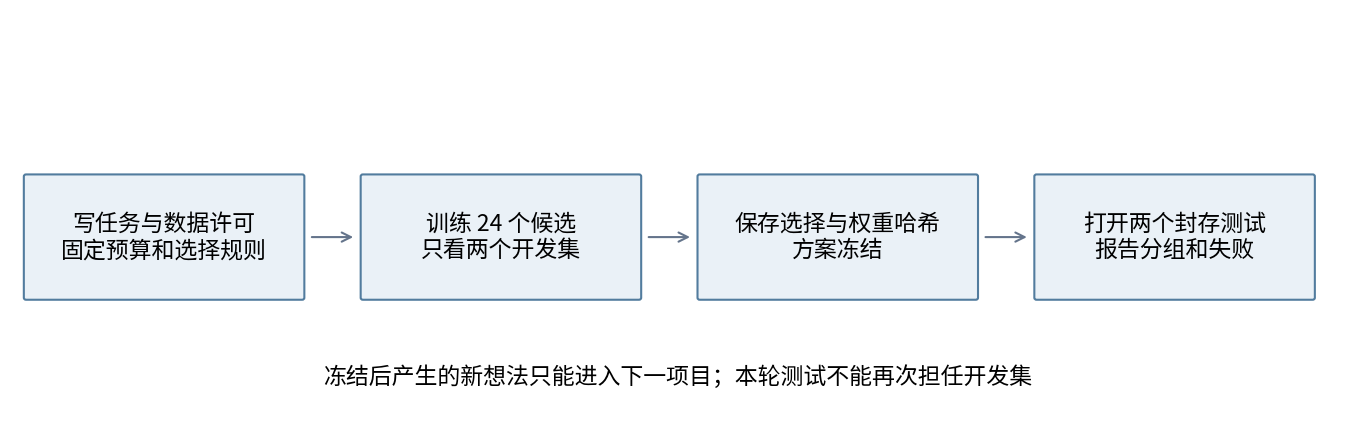

02_data_samples.png


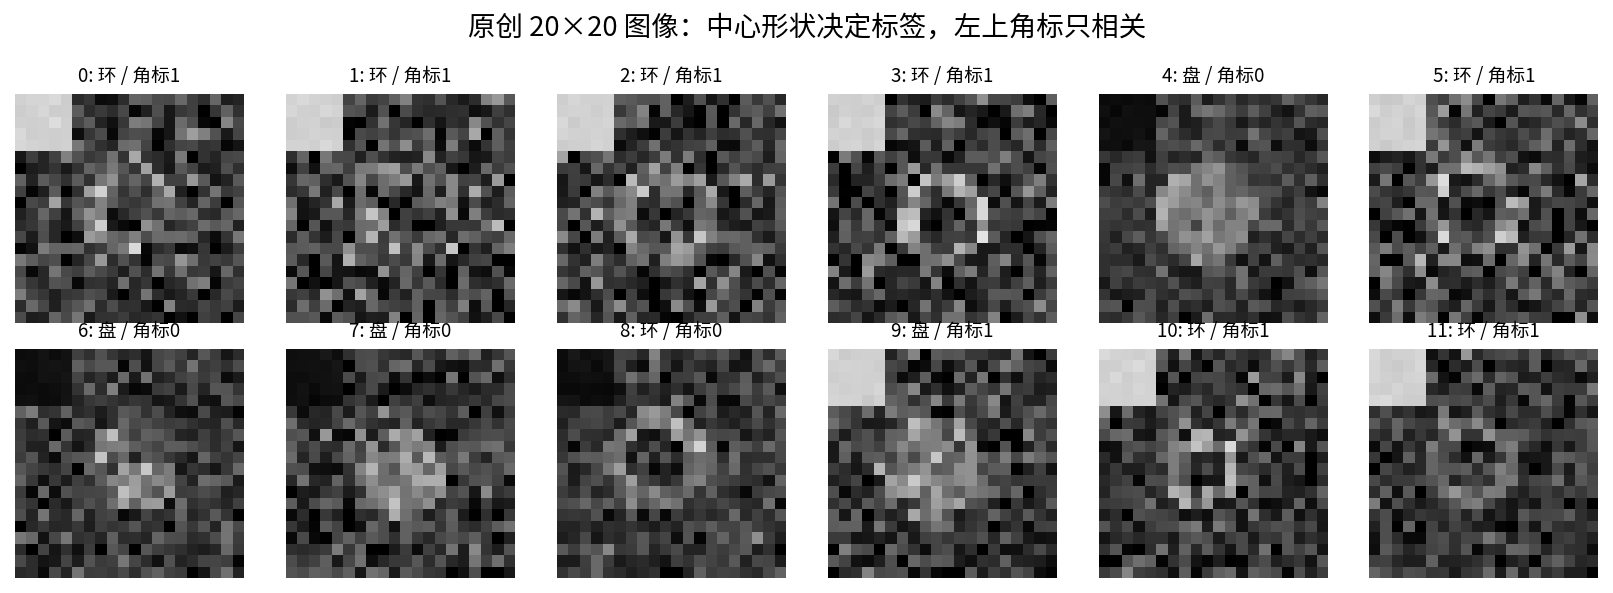

03_split_domains.png


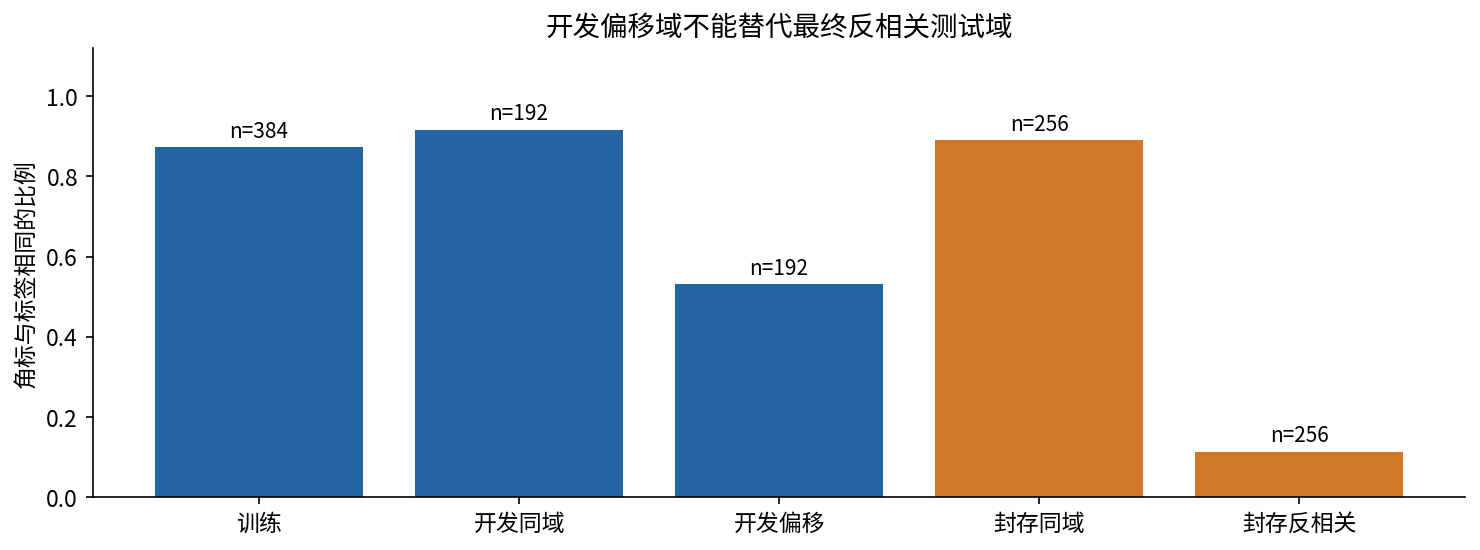

04_hand_graph.png


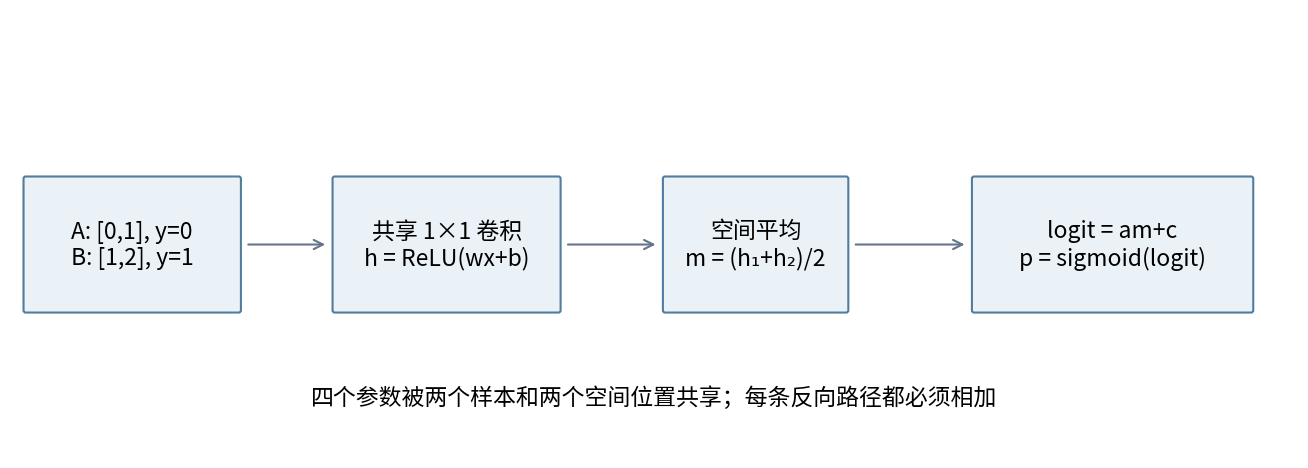

In [7]:
for name in names[:4]:
    print(name)
    display(Image(data=io.BytesIO((work/'figures'/name).read_bytes()).getvalue()))

05_hand_gradients.png


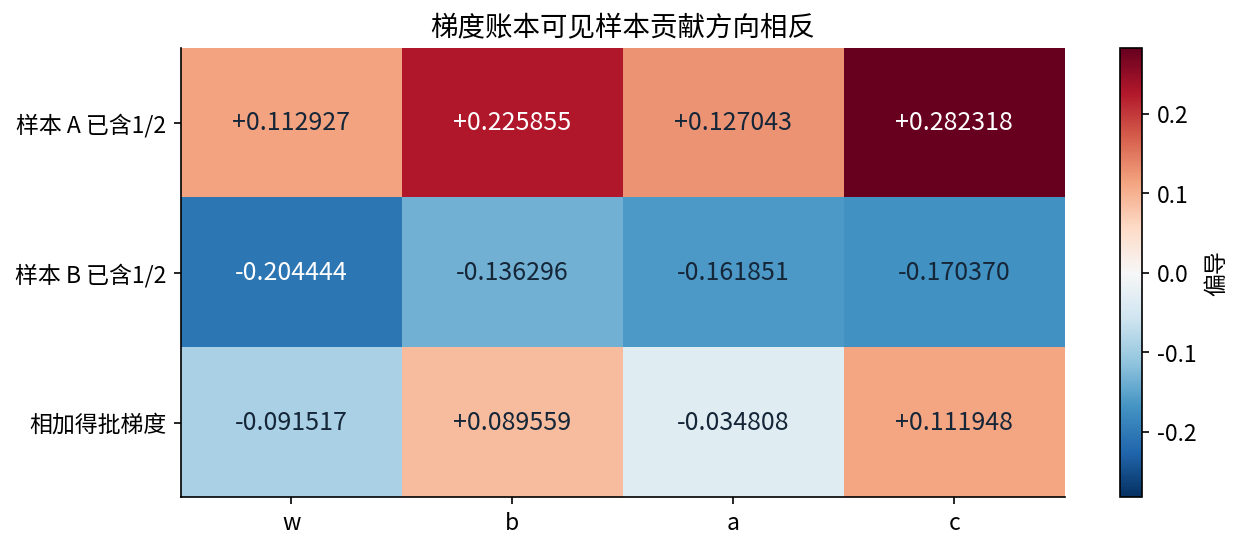

06_hand_updates.png


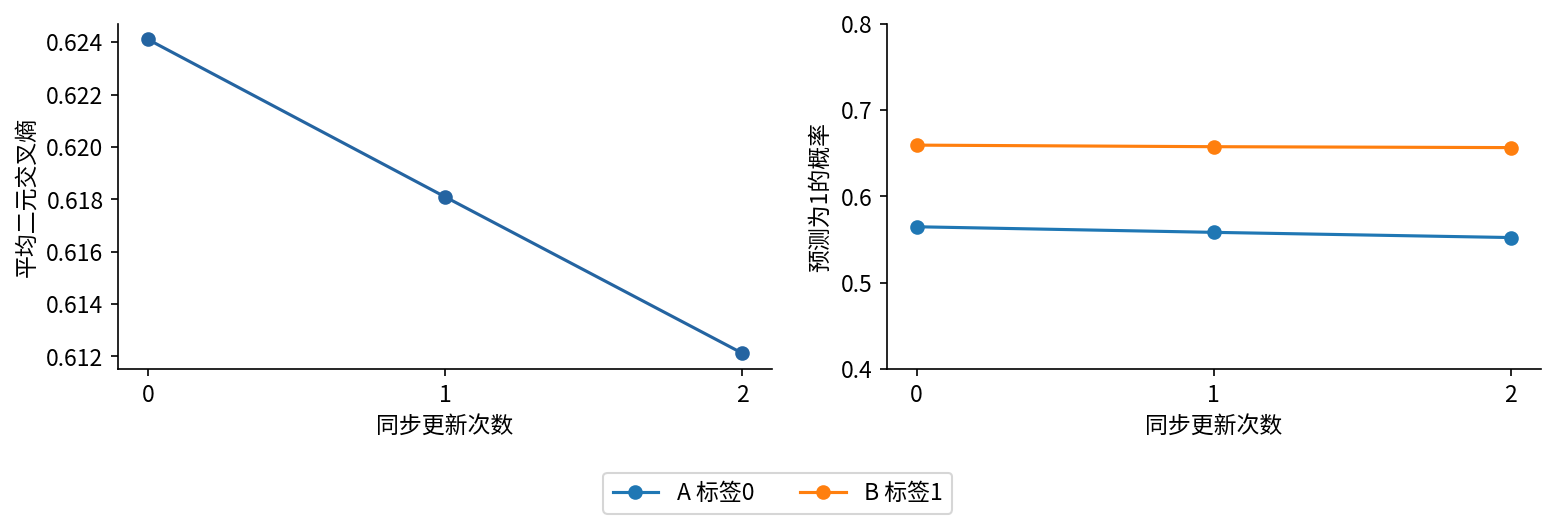

07_all_candidates.png


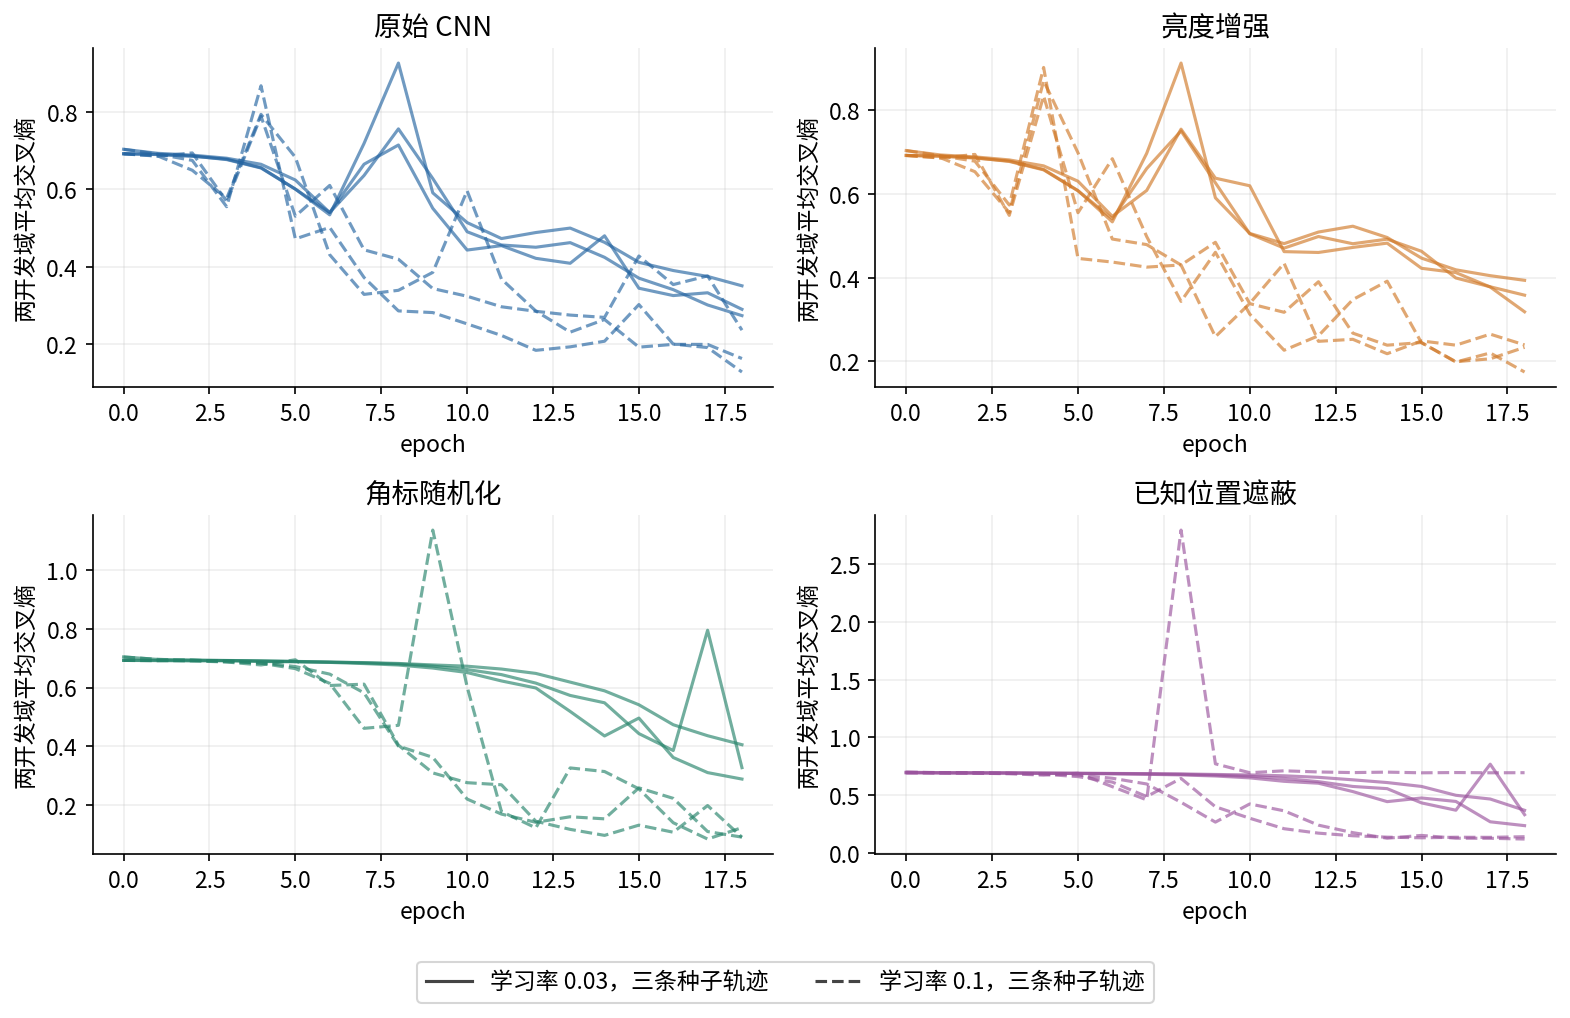

08_test_results.png


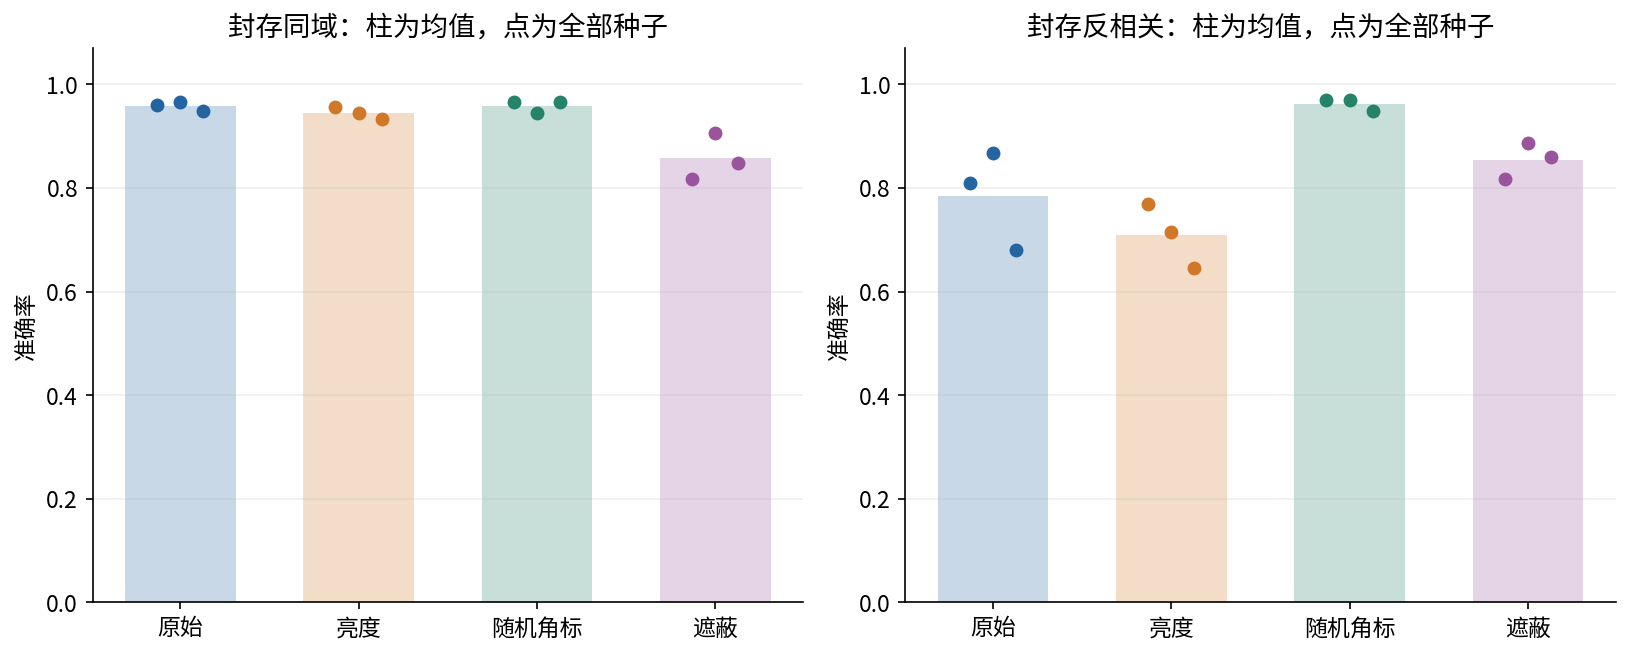

In [8]:
for name in names[4:8]:
    print(name)
    display(Image(data=io.BytesIO((work/'figures'/name).read_bytes()).getvalue()))

09_group_errors.png


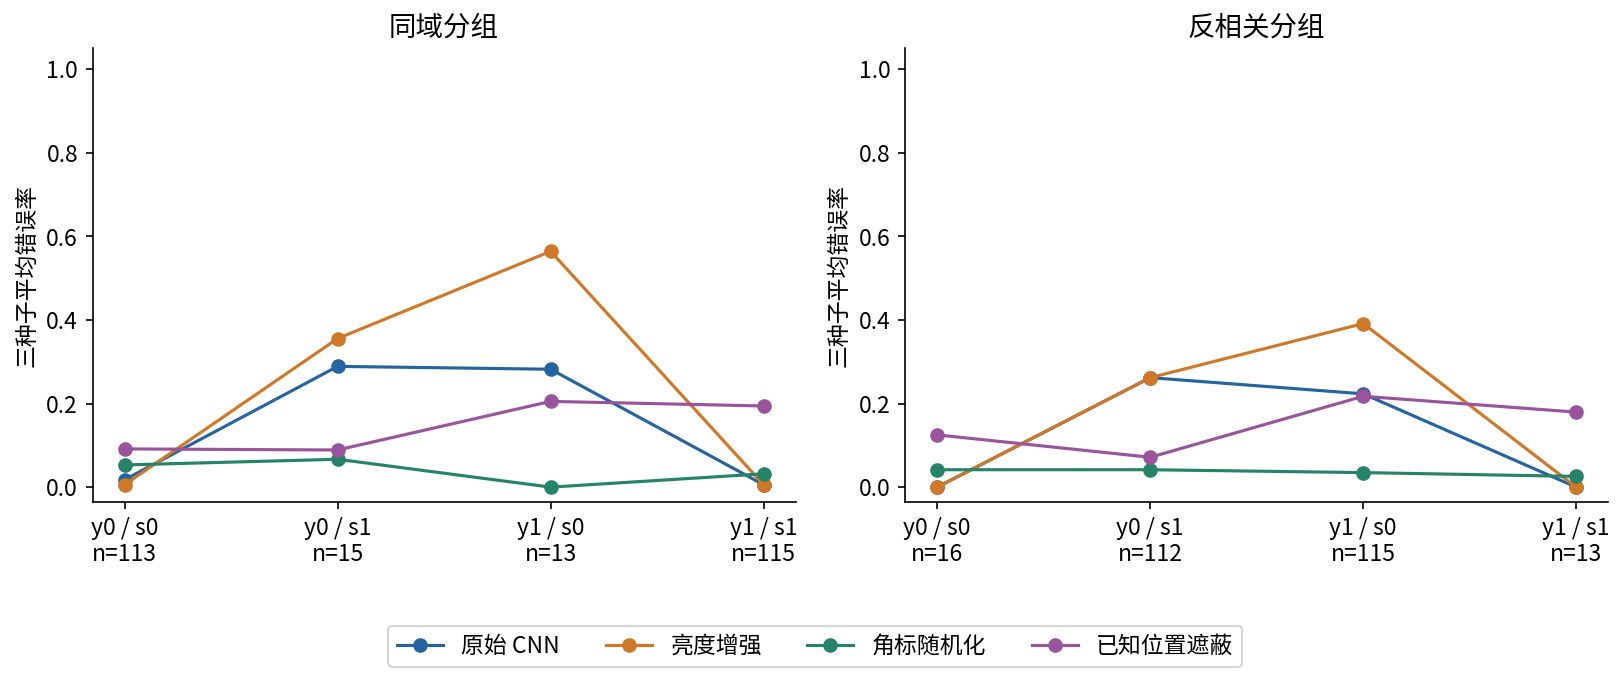

10_counterfactual.png


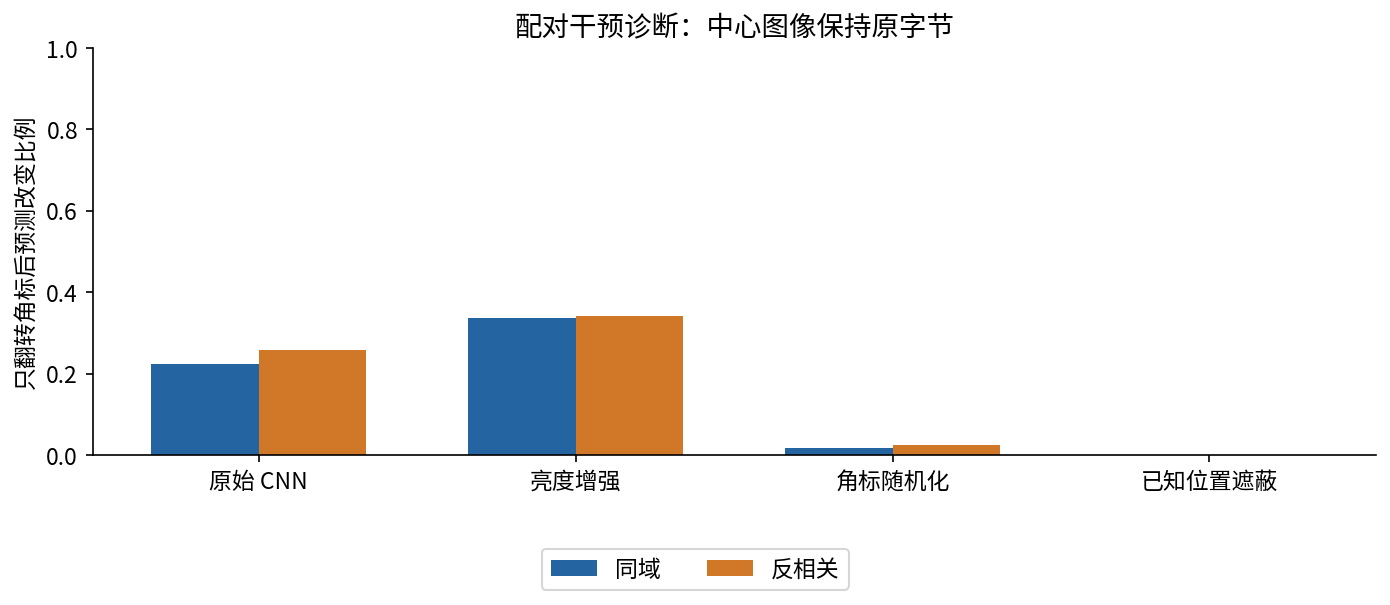

11_failure_cases.png


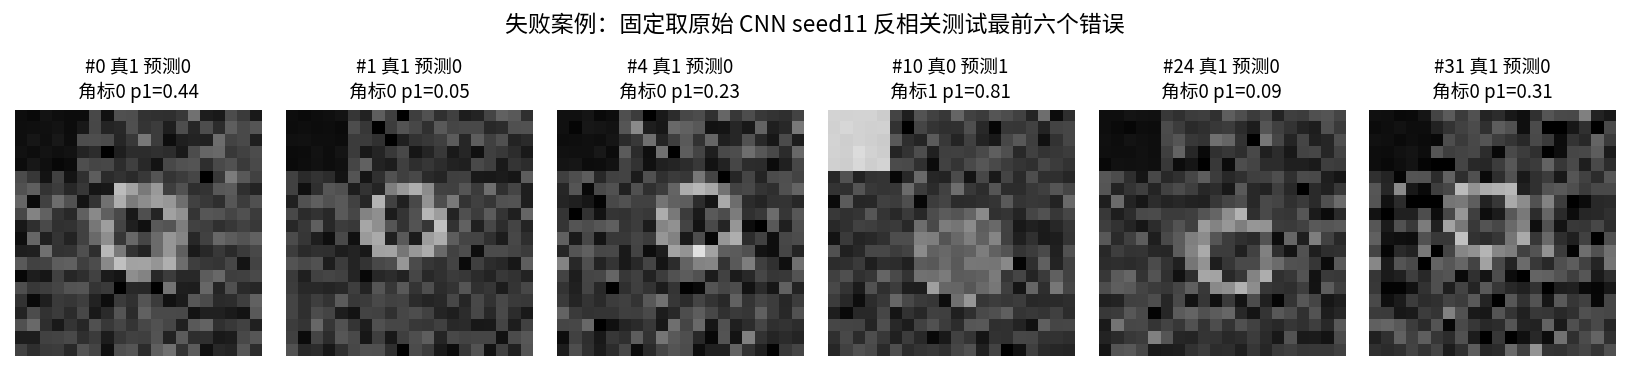

In [9]:
for name in names[8:]:
    print(name)
    display(Image(data=io.BytesIO((work/'figures'/name).read_bytes()).getvalue()))

## 研究解释
随机化保持了平均同域准确率，反相关域改善，但同域CE更高。亮度增强更差，已知位置遮蔽并未胜出。翻转角标是合成因素的局部干预，不能据此外推任意现实背景。全部12题与详解见lab.pdf及answers.pdf。